# Understanding the Youden Plot

A **Youden plot** (also called a Youden square or inter-laboratory scatter plot) is used in **measurement science and laboratory comparisons** to simultaneously assess **bias** and **precision** across multiple labs or instruments. Each lab is represented as a single point. The x-axis is the lab's measurement on material 1, and the y-axis is its measurement on material 2.

**Key insight:** If a lab has **bias** (systematic error), it will be off the centre in both x and y (shifted along the 45° diagonal). If a lab has **poor precision** (random error), it will lie far from the diagonal but in a random direction.

| Position | What it means |
|---|---|
| On the 45° diagonal, near centre | Good lab — no bias, good precision |
| Far along diagonal | Biased lab — systematically high or low |
| Far off diagonal | Imprecise lab — random error in one material |
| Far from centre AND off diagonal | Biased and imprecise |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

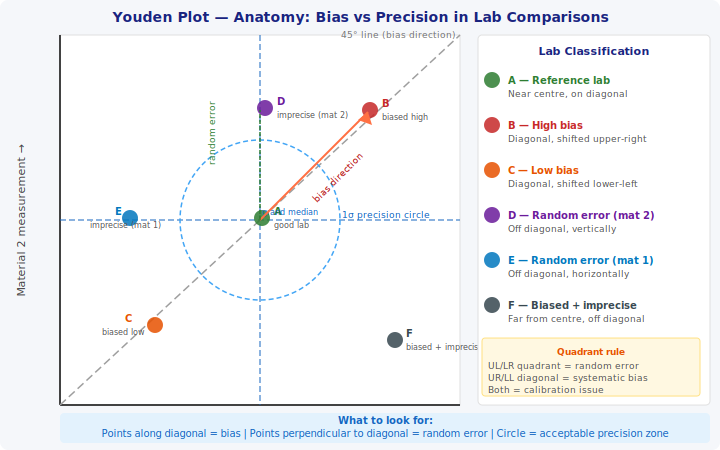

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="450"
     font-family="'Segoe UI', Arial, sans-serif">
  <rect width="720" height="450" fill="#F5F7FA" rx="8"/>
  <text x="360" y="22" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Youden Plot — Anatomy: Bias vs Precision in Lab Comparisons</text>

  <!-- ── MAIN PLOT AREA ── -->
  <rect x="60" y="35" width="400" height="370" fill="white" stroke="#E0E0E0"/>

  <!-- Axes -->
  <line x1="60"  y1="405" x2="460" y2="405" stroke="#424242" stroke-width="2"/>
  <line x1="60"  y1="405" x2="60"  y2="35"  stroke="#424242" stroke-width="2"/>

  <!-- Centre crosshairs (grand median) -->
  <line x1="60"  y1="220" x2="460" y2="220" stroke="#1565C0" stroke-width="1" stroke-dasharray="6,3"/>
  <line x1="260" y1="35"  x2="260" y2="405" stroke="#1565C0" stroke-width="1" stroke-dasharray="6,3"/>

  <!-- 45-degree diagonal (bias direction) -->
  <line x1="60" y1="405" x2="460" y2="35" stroke="#9E9E9E" stroke-width="1.5" stroke-dasharray="8,4"/>
  <text x="455" y="38" text-anchor="end" font-size="9" fill="#757575">45° line (bias direction)</text>

  <!-- Circle of precision (1σ radius) -->
  <circle cx="260" cy="220" r="80" fill="none" stroke="#42A5F5" stroke-width="1.5" stroke-dasharray="5,3"/>
  <text x="342" y="218" font-size="9" fill="#1565C0">1σ precision circle</text>

  <!-- ── LAB POINTS ── -->
  <!-- Lab A: near centre, on diagonal → good lab -->
  <circle cx="262" cy="218" r="8" fill="#2E7D32" opacity="0.85"/>
  <text x="274" y="215" font-size="10" font-weight="bold" fill="#2E7D32">A</text>
  <text x="274" y="228" font-size="8" fill="#555">good lab</text>

  <!-- Lab B: on diagonal, shifted high → biased high -->
  <circle cx="370" cy="110" r="8" fill="#C62828" opacity="0.85"/>
  <text x="382" y="107" font-size="10" font-weight="bold" fill="#C62828">B</text>
  <text x="382" y="120" font-size="8" fill="#555">biased high</text>

  <!-- Lab C: on diagonal, shifted low → biased low -->
  <circle cx="155" cy="325" r="8" fill="#E65100" opacity="0.85"/>
  <text x="125" y="322" font-size="10" font-weight="bold" fill="#E65100">C</text>
  <text x="102" y="335" font-size="8" fill="#555">biased low</text>

  <!-- Lab D: off diagonal, near vertical → imprecise in material 2 -->
  <circle cx="265" cy="108" r="8" fill="#6A1B9A" opacity="0.85"/>
  <text x="277" y="105" font-size="10" font-weight="bold" fill="#6A1B9A">D</text>
  <text x="277" y="118" font-size="8" fill="#555">imprecise (mat 2)</text>

  <!-- Lab E: off diagonal, near horizontal → imprecise in material 1 -->
  <circle cx="130" cy="218" r="8" fill="#0277BD" opacity="0.85"/>
  <text x="115" y="215" font-size="10" font-weight="bold" fill="#0277BD">E</text>
  <text x="90" y="228" font-size="8" fill="#555">imprecise (mat 1)</text>

  <!-- Lab F: far from centre, off diagonal → biased + imprecise -->
  <circle cx="395" cy="340" r="8" fill="#37474F" opacity="0.85"/>
  <text x="406" y="337" font-size="10" font-weight="bold" fill="#37474F">F</text>
  <text x="406" y="350" font-size="8" fill="#555">biased + imprecise</text>

  <!-- Axis labels -->
  <text x="260" y="425" text-anchor="middle" font-size="11" fill="#424242">Material 1 measurement →</text>
  <text x="25" y="220" text-anchor="middle" font-size="11" fill="#424242"
        transform="rotate(-90 25 220)">Material 2 measurement →</text>

  <!-- Grand median labels -->
  <text x="262" y="215" text-anchor="start" font-size="8" fill="#1565C0">grand median</text>

  <!-- ANNOTATIONS -->
  <!-- Bias direction arrow -->
  <line x1="260" y1="220" x2="368" y2="112" stroke="#FF7043" stroke-width="2"/>
  <polygon points="368,112 358,120 372,125" fill="#FF7043"/>
  <text x="340" y="180" text-anchor="middle" font-size="9" fill="#B71C1C" transform="rotate(-45 340 180)">bias direction</text>

  <!-- Precision direction arrow -->
  <line x1="260" y1="220" x2="260" y2="110" stroke="#2E7D32" stroke-width="1.5" stroke-dasharray="4,2"/>
  <text x="215" y="165" font-size="9" fill="#2E7D32" transform="rotate(-90 215 165)">random error</text>

  <!-- ── RIGHT PANEL: legend / interpretation ── -->
  <rect x="478" y="35" width="232" height="370" fill="white" stroke="#E0E0E0" rx="4"/>
  <text x="594" y="55" text-anchor="middle" font-size="11" font-weight="bold" fill="#1A237E">Lab Classification</text>

  <circle cx="492" cy="80" r="8" fill="#2E7D32" opacity="0.85"/>
  <text x="508" y="84" font-size="10" font-weight="bold" fill="#2E7D32">A — Reference lab</text>
  <text x="508" y="97" font-size="9" fill="#555">Near centre, on diagonal</text>

  <circle cx="492" cy="125" r="8" fill="#C62828" opacity="0.85"/>
  <text x="508" y="129" font-size="10" font-weight="bold" fill="#C62828">B — High bias</text>
  <text x="508" y="142" font-size="9" fill="#555">Diagonal, shifted upper-right</text>

  <circle cx="492" cy="170" r="8" fill="#E65100" opacity="0.85"/>
  <text x="508" y="174" font-size="10" font-weight="bold" fill="#E65100">C — Low bias</text>
  <text x="508" y="187" font-size="9" fill="#555">Diagonal, shifted lower-left</text>

  <circle cx="492" cy="215" r="8" fill="#6A1B9A" opacity="0.85"/>
  <text x="508" y="219" font-size="10" font-weight="bold" fill="#6A1B9A">D — Random error (mat 2)</text>
  <text x="508" y="232" font-size="9" fill="#555">Off diagonal, vertically</text>

  <circle cx="492" cy="260" r="8" fill="#0277BD" opacity="0.85"/>
  <text x="508" y="264" font-size="10" font-weight="bold" fill="#0277BD">E — Random error (mat 1)</text>
  <text x="508" y="277" font-size="9" fill="#555">Off diagonal, horizontally</text>

  <circle cx="492" cy="305" r="8" fill="#37474F" opacity="0.85"/>
  <text x="508" y="309" font-size="10" font-weight="bold" fill="#37474F">F — Biased + imprecise</text>
  <text x="508" y="322" font-size="9" fill="#555">Far from centre, off diagonal</text>

  <rect x="482" y="338" width="218" height="58" fill="#FFF8E1" stroke="#FFE082" rx="3"/>
  <text x="591" y="355" text-anchor="middle" font-size="9" font-weight="bold" fill="#E65100">Quadrant rule</text>
  <text x="488" y="369" font-size="9" fill="#555">UL/LR quadrant = random error</text>
  <text x="488" y="381" font-size="9" fill="#555">UR/LL diagonal = systematic bias</text>
  <text x="488" y="393" font-size="9" fill="#555">Both = calibration issue</text>

  <!-- Takeaway -->
  <rect x="60" y="413" width="650" height="30" fill="#E3F2FD" rx="4"/>
  <text x="385" y="424" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">What to look for:</text>
  <text x="385" y="437" text-anchor="middle" font-size="10" fill="#1565C0">Points along diagonal = bias   |   Points perpendicular to diagonal = random error   |   Circle = acceptable precision zone</text>
</svg>
"""
display(SVG(_svg))

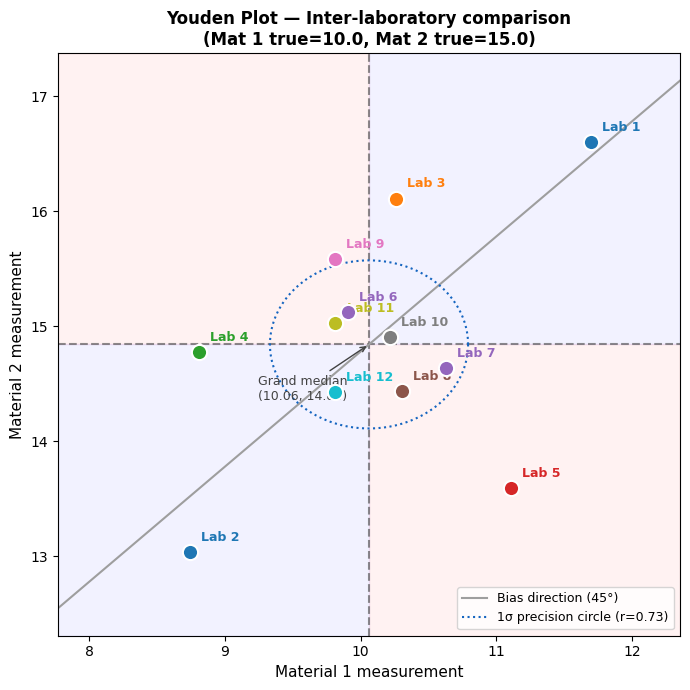

In [3]:
def youden_plot(mat1, mat2, lab_labels=None, title="Youden Plot"):
    """
    Youden inter-laboratory scatter plot.
    mat1, mat2: arrays of each lab's measurement on material 1 and 2
    """
    fig, ax = plt.subplots(figsize=(7, 7))
    grand_x = np.median(mat1)
    grand_y = np.median(mat2)

    # Quadrant shading
    x_range = max(mat1.max()-grand_x, grand_x-mat1.min()) * 1.4
    y_range = max(mat2.max()-grand_y, grand_y-mat2.min()) * 1.4
    xlim = (grand_x - x_range, grand_x + x_range)
    ylim = (grand_y - y_range, grand_y + y_range)

    ax.fill_betweenx([grand_y, ylim[1]], xlim[0], grand_x, alpha=0.05, color='red')
    ax.fill_betweenx([ylim[0], grand_y], grand_x, xlim[1], alpha=0.05, color='red')
    ax.fill_betweenx([grand_y, ylim[1]], grand_x, xlim[1], alpha=0.05, color='blue')
    ax.fill_betweenx([ylim[0], grand_y], xlim[0], grand_x, alpha=0.05, color='blue')

    # Centre crosshairs
    ax.axhline(grand_y, color='#424242', linewidth=1.5, linestyle='--', alpha=0.6)
    ax.axvline(grand_x, color='#424242', linewidth=1.5, linestyle='--', alpha=0.6)

    # 45° diagonal
    diag_range = np.array([min(xlim[0], ylim[0]), max(xlim[1], ylim[1])])
    offset = grand_y - grand_x
    ax.plot(diag_range, diag_range + offset, '-', color='#9E9E9E', linewidth=1.5, label='Bias direction (45°)')

    # Precision circle (1σ of distances from centre)
    distances = np.sqrt((mat1 - grand_x)**2 + (mat2 - grand_y)**2)
    radius = np.std(distances)
    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(grand_x + radius*np.cos(theta), grand_y + radius*np.sin(theta),
            ':', color='#1565C0', linewidth=1.5, label=f'1σ precision circle (r={radius:.2f})')

    # Lab points
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(mat1)))
    for i, (x, y, color) in enumerate(zip(mat1, mat2, colors)):
        label = lab_labels[i] if lab_labels else f'Lab {i+1}'
        ax.scatter(x, y, color=color, s=120, zorder=5, edgecolors='white', linewidths=1.5)
        ax.annotate(label, (x, y), xytext=(8, 8), textcoords='offset points',
                    fontsize=9, fontweight='bold', color=color)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('Material 1 measurement', fontsize=11)
    ax.set_ylabel('Material 2 measurement', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')

    # Grand median annotation
    ax.annotate(f'Grand median\n({grand_x:.2f}, {grand_y:.2f})',
                (grand_x, grand_y), xytext=(-80, -40), textcoords='offset points',
                fontsize=9, color='#424242',
                arrowprops=dict(arrowstyle='->', color='#424242'))
    plt.tight_layout()
    plt.show()

np.random.seed(42)
n_labs = 12
# Reference value material 1 = 10.0, material 2 = 15.0
ref_x, ref_y = 10.0, 15.0

# Generate synthetic lab data with varying bias and precision
mat1 = ref_x + np.random.normal(0, 0.4, n_labs)
mat2 = ref_y + np.random.normal(0, 0.4, n_labs)

# Add specific patterns
mat1[0] += 1.5; mat2[0] += 1.5   # Lab 1: biased high
mat1[1] -= 1.2; mat2[1] -= 1.2   # Lab 2: biased low
mat1[2] += 0.0; mat2[2] += 1.8   # Lab 3: random error in mat 2
mat1[3] -= 1.8; mat2[3] += 0.0   # Lab 4: random error in mat 1
mat1[4] += 1.2; mat2[4] -= 1.0   # Lab 5: biased + imprecise

labs = [f'Lab {i+1}' for i in range(n_labs)]
youden_plot(mat1, mat2, lab_labels=labs,
            title="Youden Plot — Inter-laboratory comparison\n(Mat 1 true=10.0, Mat 2 true=15.0)")

## Key Takeaways

| | |
|---|---|
| **Domain** | Metrology, inter-laboratory proficiency testing |
| **x-axis** | Lab's result for material 1 |
| **y-axis** | Lab's result for material 2 |
| **Centre crosshairs** | Grand median (consensus reference value) |
| **45° diagonal** | Direction of systematic bias |
| **Along diagonal** | Systematic bias — lab's instrument is miscalibrated |
| **Perpendicular to diagonal** | Random error — precision problem |
| **Precision circle** | Labs inside are acceptably precise |
| **Both bias + off diagonal** | Calibration + random error — recalibrate and investigate |
| **vs scatter plot** | Youden plot specifically interprets diagonal vs perpendicular displacement |